# Test the ported code of VoxelMorph

In [4]:
%load_ext autoreload
%autoreload 2
from constraints.voxelmorph.models import VxmPairwise

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
import torch
import torchvision
import torchvision.transforms.v2 as T
import matplotlib.pyplot as plt
import numpy as np
import neurite as ne
from torch import nn
import tqdm

device = "cpu"

mnist = torchvision.datasets.MNIST(
    root="./mnist-data",
    train=True,
    download=True,
    transform=T.Compose([T.ToTensor(),T.ToDtype(torch.float32, scale=True),T.Pad(2)]),)

60000
First image shape: torch.Size([1, 32, 32]), label: 5


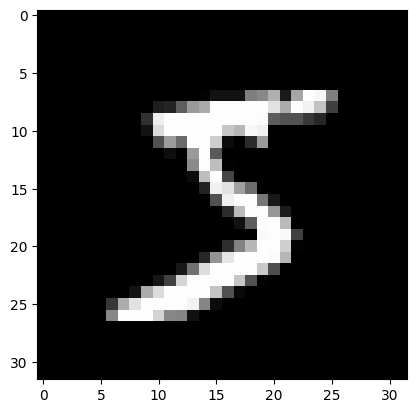

In [6]:
print( len(mnist) )
first_image, first_label = mnist[0]
print(f"First image shape: {first_image.shape}, label: {first_label}")
plt.imshow(first_image.squeeze(), cmap="gray")
from collections import defaultdict
import random

by_digit = defaultdict(list)
for i, (img, label) in enumerate(mnist):
    by_digit[label].append(img)


Training on digit 5 with torch.Size([5421, 1, 32, 32]) samples.
Train: torch.Size([4336, 1, 32, 32]), Val: torch.Size([542, 1, 32, 32]), Test: torch.Size([543, 1, 32, 32])


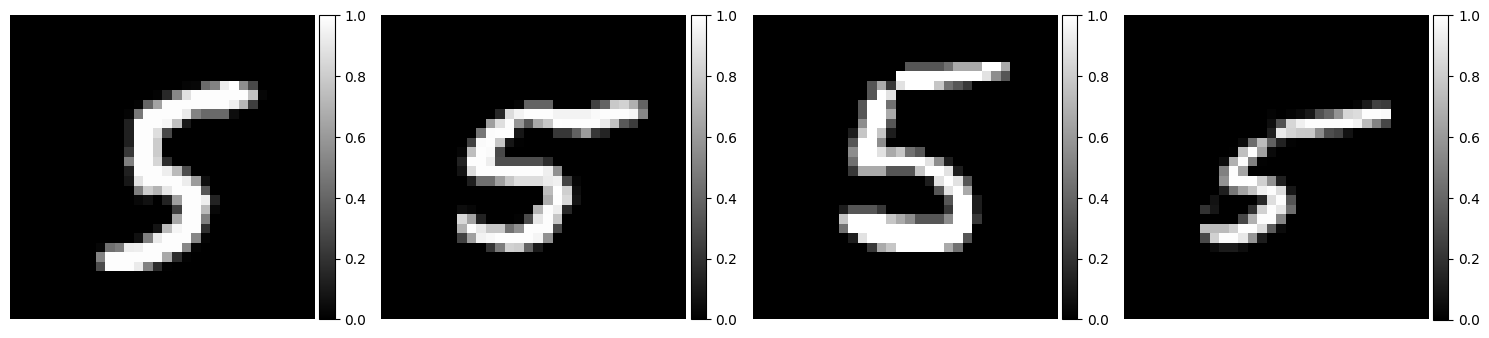

In [7]:
digit_sel = 5
x = torch.stack(by_digit[digit_sel]).to(device)
print(f"Training on digit {digit_sel} with {x.shape} samples.")

trn_p,val_p,tst_p = 0.8, 0.1, 0.1
n = x.shape[0]
trn_end = int(n * trn_p)
val_end = trn_end + int(n * val_p)
x_train, x_val, x_tst = x[:trn_end], x[trn_end:val_end], x[val_end:]
print(f"Train: {x_train.shape}, Val: {x_val.shape}, Test: {x_tst.shape}")
idx = np.random.choice(x_train.shape[0], 4, replace=False)
example_digits = [f for f in x_train[idx, ...]]

# plot
ne.plot.slices(example_digits, cmaps=['gray'], do_colorbars=True);


In [9]:

nb_features = [
    [32, 32, 32, 32], # encoder features
    [32, 32, 32, 32]  # decoder features
]

model = VxmPairwise(
    ndim=2,
    source_channels=1,
    target_channels=1,
    nb_features=nb_features,
)
image_loss_fn = ne.nn.modules.MSE()
grad_loss_fn = ne.nn.modules.SpatialGradient('l2')

In [13]:
from collections.abc import Sequence
def train_epoch(
    model: nn.Module,
    dataloader: torch.utils.data.DataLoader,
    optimizer: torch.optim.Optimizer,
    image_loss_fn: nn.Module,
    grad_loss_fn: nn.Module,
    loss_weights: Sequence[float],
    steps_per_epoch: int,
    device: str = 'cuda'
) -> float:
    """
    Train for one epoch.

    Parameters
    ----------
    model : nn.Module
        The VoxelMorph model to train.
    dataloader : torch.utils.data.DataLoader
        The dataloader to use for training.
    optimizer : torch.optim.Optimizer
        The optimizer to use for training.
    image_loss_fn : nn.Module
        The image loss function to use.
    grad_loss_fn : nn.Module
        The gradient loss function to use.
    loss_weights : Sequence[float]
        The weights for the image and gradient losses.
    steps_per_epoch : int
    """

    model.train()
    total_loss = 0.0

    for _ in range(steps_per_epoch):
        batch = next(dataloader)
        optimizer.zero_grad()

        # Move to device in training loop (not dataloader/dataset!)
        source = batch['source'].to(device)
        target = batch['target'].to(device)

        # Get the displacement and the warped source image from the model
        displacement, warped_source = model(
            source,
            target,
            return_warped_source=True,
            return_field_type='displacement'
        )

        img_loss = image_loss_fn(target, warped_source)
        grad_loss = grad_loss_fn(displacement)

        loss = loss_weights[0] * img_loss + loss_weights[1] * grad_loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / steps_per_epoch

In [14]:
from torch.utils.data import IterableDataset
class VxmIterableDataset(IterableDataset):
    """
    PyTorch IterableDataset for infinite VoxelMorph registration data.
    """

    def __init__(self, imgs: torch.Tensor, device: str = 'cpu') -> None:
        """
        Parameters
        ----------
        img_glob : str
            Glob pattern for training volumes. Supported formats are those accepted by
            vxm.py.utils.load_volfile, for example NIfTI, MGZ, NPZ, or NPY.
        ndim : int
            Number of spatial dimensions in each image.
        device : str
            Device to place tensors on.
        """

        self.device = device
        self.imgs = imgs

    def __iter__(self):
        """
        Generate infinite stream of random volume pairs.

        Yields
        ------
        dict
            A dictionary containing the source and target volumes.
        """
        while True:
            idx1, idx2 = np.random.randint(0, len(self.imgs), size=2)
            source = self.imgs[idx1]
            target = self.imgs[idx2]
            yield {'source': source, 'target': target}


In [16]:
# voxelmorph has a variety of custom loss classes


# usually, we have to balance the two losses by a hyper-parameter
lambda_param = 0.05
loss_weights = [1, lambda_param]

In [17]:
from torch.utils.data import DataLoader
losses = []

dataset = VxmIterableDataset(
    x_train,
    device=device
)
for epoch in tqdm.tqdm(range(70),desc="Training Epochs"):
    train_loss = train_epoch(
        model=model,
        dataloader=iter(DataLoader(dataset, batch_size=16)),
        optimizer=torch.optim.Adam(model.parameters(), lr=1e-4),
        image_loss_fn=image_loss_fn,
        grad_loss_fn=grad_loss_fn,
        loss_weights=loss_weights,
        steps_per_epoch=100,
        device=device
    )
    losses.append(train_loss)
    print(f"Epoch {epoch + 1}: Train Loss = {train_loss:.6f}")

Training Epochs:   1%|▏         | 1/70 [00:04<05:40,  4.94s/it]

Epoch 1: Train Loss = 0.087361


Training Epochs:   3%|▎         | 2/70 [00:09<05:27,  4.82s/it]

Epoch 2: Train Loss = 0.079495


Training Epochs:   4%|▍         | 3/70 [00:14<05:22,  4.81s/it]

...

Epoch 68: Train Loss = 0.016653


Training Epochs:  99%|█████████▊| 69/70 [05:27<00:05,  5.02s/it]

Epoch 69: Train Loss = 0.016970


Training Epochs: 100%|██████████| 70/70 [05:32<00:00,  4.76s/it]

Epoch 70: Train Loss = 0.016863


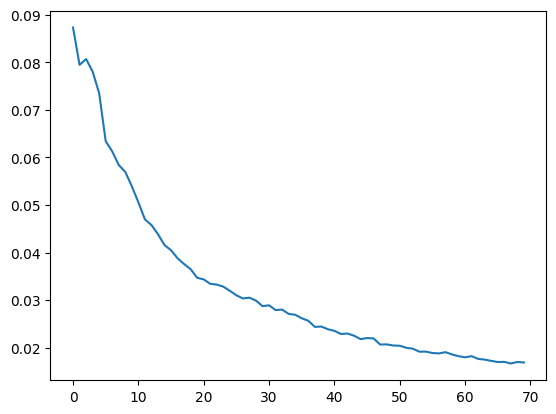

In [18]:
plt.plot(losses)

Moving image shape: torch.Size([1, 1, 32, 32])
Fixed image shape: torch.Size([1, 1, 32, 32])
Moved image shape: torch.Size([1, 1, 32, 32])
Moving image shape: torch.Size([32, 32])


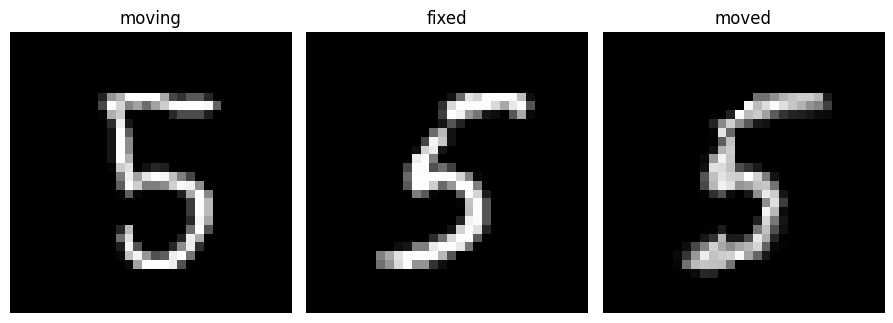

In [19]:
TST_IDX = 20

model.eval()
with torch.no_grad():
    warp,moved = model(
        x_tst[TST_IDX:TST_IDX+1],
        x_tst[TST_IDX+1:TST_IDX+2],
        return_warped_source=True,
        return_field_type='displacement'
    )
print(f"Moving image shape: {x_tst[TST_IDX:TST_IDX+1].shape}")
print(f"Fixed image shape: {x_tst[TST_IDX+1:TST_IDX+2].shape}")
print(f"Moved image shape: {moved.shape}")
images = [x_tst[TST_IDX:TST_IDX+1], x_tst[TST_IDX+1:TST_IDX+2], moved]
images = [img.squeeze().cpu() for img in images]
print(f"Moving image shape: {images[0].shape}")

titles = ['moving', 'fixed', 'moved', 'flow']
plt.figure(figsize=(12, 4))
for i, (img, title) in enumerate(zip(images, titles)):
    plt.subplot(1, 4, i + 1)
    plt.imshow(img, cmap='gray', origin='lower')
    plt.gca().invert_yaxis()
    plt.title(title)
    plt.axis('off')
plt.tight_layout()
plt.show()
# ne.plot.slices(images, titles=titles, cmaps=['gray'], do_colorbars=True);